In [1]:
from option_finder import *
from option_chain_downloader import OptionChainDownloader
import matplotlib.pyplot as plt

In [2]:
try:
    logger
except NameError:
    logger = get_rotating_logger("jupyter", f'logs/leaps_latest.log')

In [3]:
chain_dir = 'chain'
quotes_dir = 'quotes'
leaps_dir = 'leaps'
data_dir = 'data'
cookie_file = 'cookie.txt'
self = OptionFinder(logger, chain_dir=leaps_dir, report_dir=data_dir)
ocd = OptionChainDownloader(chain_dir, quotes_dir, leaps_dir, cookie_file, logger, strikes='ALL')

In [4]:
#symlist = ['SPY'] # TLT GLD IBIT'.split(' ')
symlist = 'QQQ SPY TLT DIA IBIT ETHA GLD SLV'.split(' ')
#symlist = 'QQQ SPY TLT DIA IBIT GLD'.split(' ')

## Refresh data here

In [5]:
_t0 = time.time()
_n = ocd.download_option_chain(symlist, batch_size=0)
print(_n, 'files downloaded', int(time.time() - _t0), 'seconds')

24 files downloaded 37 seconds


In [6]:
self.get_quote_df(symlist)
_df = self.build_option_df(symlist)
_df = self.separate_df(_df, 'call')
df_leaps = self.sort_leaps_df(_df)
df_leaps['leverage'] = df_leaps.lastPrice/df_leaps.mid*df_leaps.Delta
df_leaps['overpaid'] = (df_leaps.mid + df_leaps.strike)/df_leaps.lastPrice - 1

sort_leaps_df neglected columns: ['pctProfit', 'Bid', 'Ask', 'Last', 'Change', 'Volume', 'TimeValue', 'IntrinsicValue', 'Rho', 'optionPeriodicity', 'quote_dt']


### Leaps option overview: number of strikes, strike range, delta range

### Leap option spread distributions

### Leap option open interests

In [7]:
delta_lb = 0.65
overpaid_ub = 0.05
price_lb = 10
spread_ub = 5
leverage_lb = 3
openinterest_lb = 10
_filter = (df_leaps.Delta >= delta_lb) & (df_leaps.overpaid <= overpaid_ub) & (df_leaps.mid >= price_lb) & (df_leaps.pctSpread <= spread_ub)
_filter = _filter & (df_leaps.leverage >= leverage_lb) & (df_leaps.OpenInterest >= openinterest_lb)
_df = df_leaps[_filter].set_index(['symbol', 'expDt']).sort_values(by='leverage', ascending=False)
_df[_df.index.get_level_values('symbol') != '_'].head(60)

strike  dte     mid  pctSpread  lastPrice    Delta  \
symbol expDt                                                            
SPY    2025-12-31   657.0   90  30.875   0.226978     669.22  0.65107   
       2025-12-31   656.0   90  31.630   0.253245     669.22  0.65743   
GLD    2025-12-31   348.0   90  16.825   2.710843     354.79  0.65214   
SPY    2025-12-31   655.0   90  32.390   0.247295     669.22  0.66364   
GLD    2025-12-31   347.0   90  17.450   2.906977     354.79  0.66550   
       2025-12-31   346.0   90  18.050   2.808989     354.79  0.67861   
       2025-12-31   345.0   90  18.700   2.710027     354.79  0.69185   
SPY    2025-12-31   651.0   90  35.485   0.253950     669.22  0.68755   
GLD    2025-12-31   344.0   90  19.375   1.822917     354.79  0.70442   
SPY    2025-12-31   650.0   90  36.270   0.220811     669.22  0.69308   
GLD    2026-01-16   348.0  106  18.075   2.521008     354.79  0.65070   
       2025-12-31   343.0   90  20.050   2.525253     354.79  0.71709   
       2026-01-16   347.0  106  18.675   2.439024     354.79  0.66306   
       2025-12-31   342.0   90  20.750   2.439024     354.79  0.72895   
       2026-01-16   346.0  106  19.300   2.624672     354.79  0.67528   
SPY    2026-01-16   655.0  106  35.420   0.226116     669.22  0.65507   
GLD    2025-12-31   341.0   90  21.425   2.600473     354.79  0.74128   
       2026-01-16   345.0  106  19.925   2.284264     354.79  0.68732   
       2025-12-31   340.0   90  22.150   2.283105     354.79  0.75315   
       2026-01-16   344.0  106  20.600   1.960784     354.79  0.69910   
       2025-12-31   339.0   90  22.850   2.660754     354.79  0.76454   
       2026-01-16   343.0  106  21.250   2.380952     354.79  0.71069   
       2026-01-16   342.0  106  21.900   2.309469     354.79  0.72263   
       2025-12-31   338.0   90  23.625   2.355460     354.79  0.77532   
SPY    2026-01-30   655.0  120  37.660   0.212653     669.22  0.65465   
       2026-01-16   650.0  106  39.250   0.204030     669.22  0.68164   
GLD    2026-01-16   341.0  106  22.600   2.237136     354.79  0.73378   
SPY    2026-01-30   654.0  120  38.415   0.234558     669.22  0.65978   
GLD    2025-12-31   337.0   90  24.375   2.282158     354.79  0.78639   
SPY    2026-01-30   653.0  120  39.170   0.204447     669.22  0.66490   
GLD    2026-01-16   340.0  106  23.300   2.169197     354.79  0.74492   
       2025-12-31   336.0   90  25.150   2.008032     354.79  0.79707   
SPY    2025-12-31   640.0   90  44.355   1.751194     669.22  0.74438   
       2026-01-30   652.0  120  39.930   0.200552     669.22  0.66991   
GLD    2026-01-16   339.0  106  24.050   2.100840     354.79  0.75517   
SPY    2026-01-30   651.0  120  40.695   0.221402     669.22  0.67489   
GLD    2025-12-31   335.0   90  25.925   2.144250     354.79  0.80764   
       2026-01-16   338.0  106  24.750   2.040816     354.79  0.76636   
SPY    2026-01-16   645.0  106  43.145   1.236007     669.22  0.70750   
       2026-01-30   650.0  120  41.465   0.217286     669.22  0.67972   
QQQ    2025-12-31   590.0   90  36.360   0.773054     605.73  0.65508   
SPY    2026-01-30   649.0  120  42.235   0.213321     669.22  0.68446   
GLD    2025-12-31   334.0   90  26.725   2.079395     354.79  0.81691   
       2026-01-16   337.0  106  25.500   1.980198     354.79  0.77658   
       2026-02-20   345.0  141  22.350   2.262443     354.79  0.67974   
SPY    2026-01-30   648.0  120  43.015   0.209448     669.22  0.68923   
       2026-02-20   655.0  141  40.930   0.195647     669.22  0.65420   
GLD    2025-12-31   333.0   90  27.500   2.205882     354.79  0.82646   
       2026-01-16   336.0  106  26.250   1.923077     354.79  0.78696   
SPY    2026-01-30   647.0  120  43.795   0.205714     669.22  0.69388   
       2025-12-31   635.0   90  48.540   1.619938     669.22  0.76639   
       2026-01-30   646.0  120  44.580   0.224568     669.22  0.69845   
GLD    2025-12-31   332.0   90  28.275   2.688172     354.79  0.83549   
    

SPY 12 DTEs [90, 106, 120, 141, 148, 169, 180, 259, 271, 351, 442, 470]
GLD 10 DTEs [90, 106, 141, 169, 180, 225, 259, 271, 351, 470]
QQQ 9 DTEs [90, 106, 141, 169, 180, 197, 259, 271, 351]
TLT 12 DTEs [90, 106, 141, 169, 180, 197, 225, 259, 271, 351, 363, 470]
DIA 7 DTEs [90, 106, 169, 180, 259, 442, 470]
IBIT 3 DTEs [90, 106, 141]
SLV 10 DTEs [90, 106, 141, 169, 180, 197, 259, 271, 351, 470]


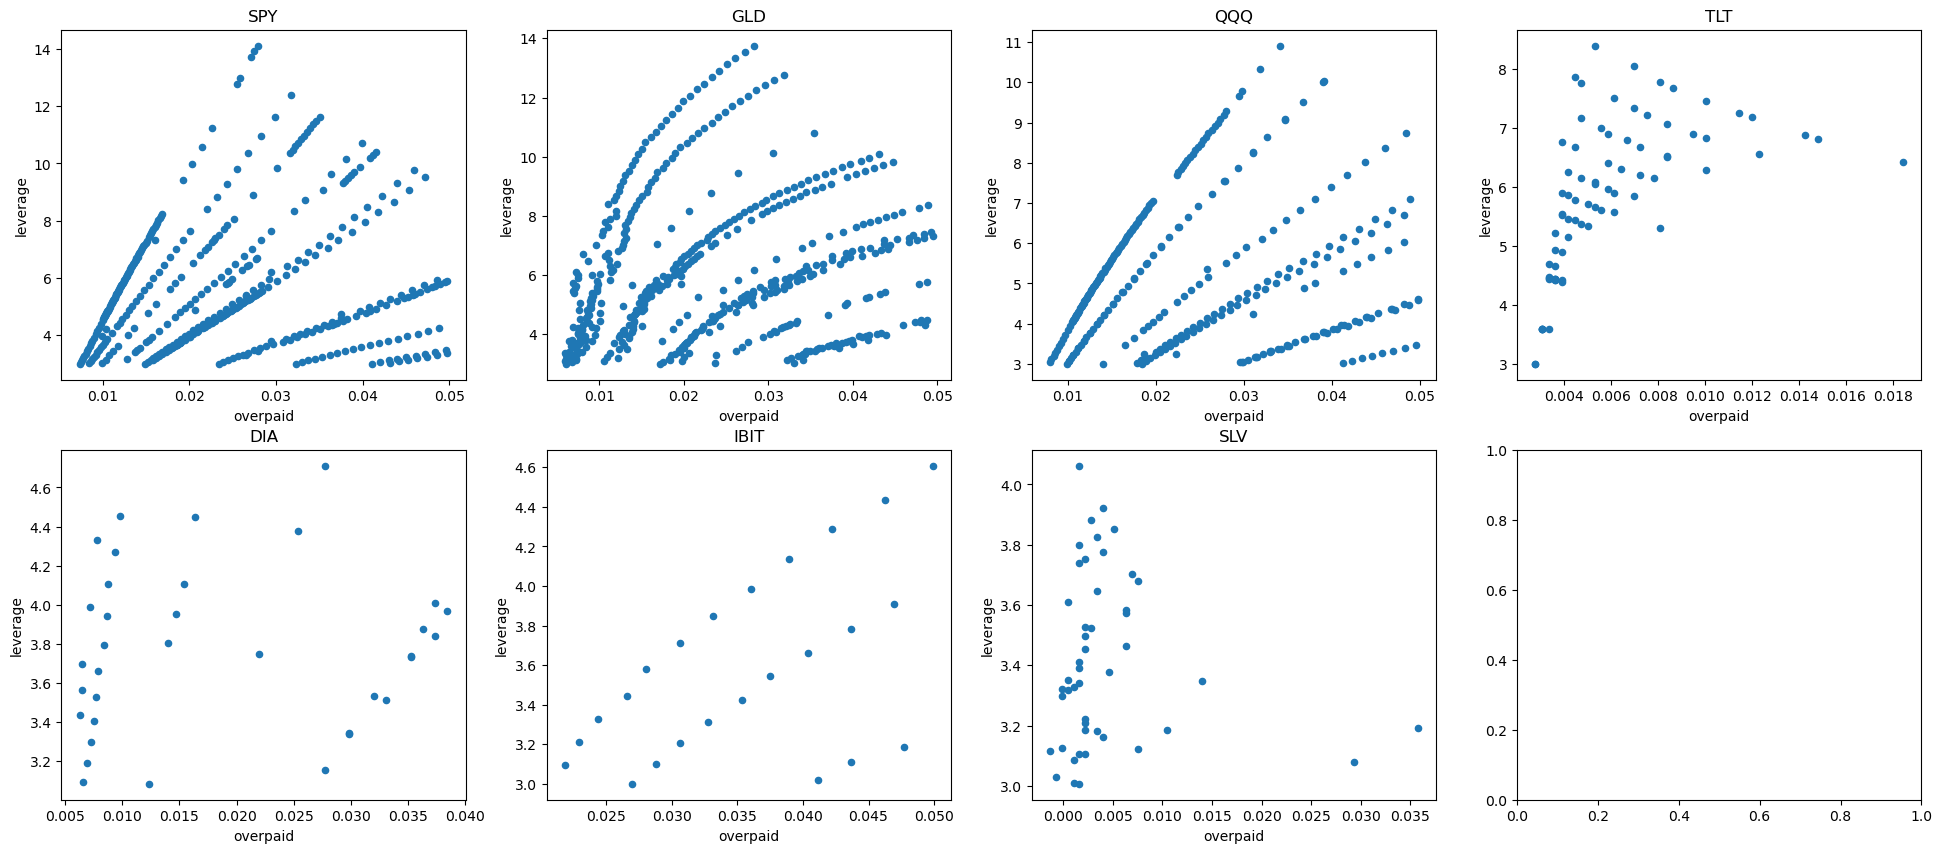

In [8]:
plt.rcParams['figure.figsize'] = (24, 10)
_symlist = list(_df.index.get_level_values('symbol').unique())
if len(_symlist) <= 4:
    nr = 1
else:
    nr = 2
nc = int(np.ceil(len(_symlist)/nr))
fig, ax = plt.subplots(nr, nc)
for i, symbol in enumerate(_symlist):
    _dte = sorted(_df.loc[symbol].dte.unique())
    print(symbol, len(_dte), 'DTEs', _dte)
    if nr == 1:
        _df.loc[symbol][(_df.overpaid <= overpaid_ub)].plot(kind='scatter', x='overpaid', y='leverage', ax=ax[i%nc], title=symbol)
    else:
        _df.xs(symbol, level='symbol').plot(kind='scatter', x='overpaid', y='leverage', ax=ax[i//nc, i%nc], title=symbol)

### The End